In [12]:
from neural_priors.utils.data import Subject, get_all_subject_ids
from tqdm.contrib.itertools import product
import pandas as pd
import seaborn as sns

In [13]:
fit_responses_ = [True,False]
censored = [True, False]
subjects = get_all_subject_ids()
models = [14, 15]

In [14]:
df = []

for subject, model_label, fit_responses, cens in product(subjects, models, fit_responses_, censored):
    try:
        d = Subject(subject).get_prf_parameters_volume(roi='NPCr', model_label=model_label, response_fit=fit_responses, censored=cens)
        d['subject'] = subject
        d['model_label'] = model_label
        d['fit_responses'] = fit_responses
        d['censored'] = cens
        df.append(d.set_index(['subject', 'model_label', 'fit_responses', 'censored'], append=True))
    except Exception as e:
        print(f"Error processing subject {subject}, model {model_label}, fit_responses {fit_responses}, censored {cens}: {e}")

df = pd.concat(df)


df.to_csv('/data/ds-neuralpriors/derivatives/summary_tsvs/censored_models_sd_scale.tsv', sep='\t')

  0%|          | 0/312 [00:00<?, ?it/s]

In [15]:
df = pd.read_csv('/data/ds-neuralpriors/derivatives/summary_tsvs/censored_models_sd_scale.tsv', sep='\t', index_col=[0,1,2,3,4], header=[0,1])

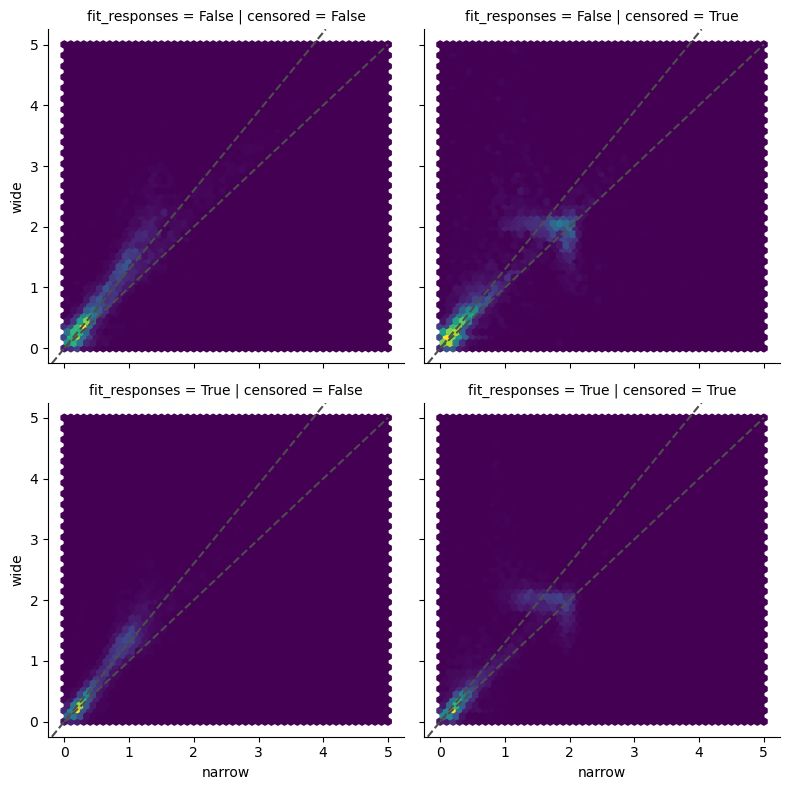

In [16]:
import matplotlib.pyplot as plt
mus = df[df[('cvr2', 'nan')] > 0.0]['sd']

max_sd = 5.0

def hexbin(x, y, color, **kwargs):
    cmap = sns.light_palette(color, as_cmap=True)
    cmap='viridis'
    plt.hexbin(x, y, gridsize=50, cmap=cmap, **kwargs)

g = sns.FacetGrid(mus.xs(14, level='model_label').reset_index(), col="censored", hue='censored', height=4, row='fit_responses')
g.map(hexbin, "narrow", "wide", extent=[0, max_sd, 0, max_sd])

# Identity line
for ax in g.axes.flatten():
    ax.plot([0, max_sd], [0, max_sd], ls="--", c=".3")

    ax.axline((0, 0), slope=1.3  , ls="--", c=".3")

# for ax in g.axes.flatten():
#     #plot [10, 10] to [25, 40]
#     ax.plot([10, 25], [10, 40], ls="--", c=".3")

<Axes: xlabel="('mu', 'narrow')", ylabel='Count'>

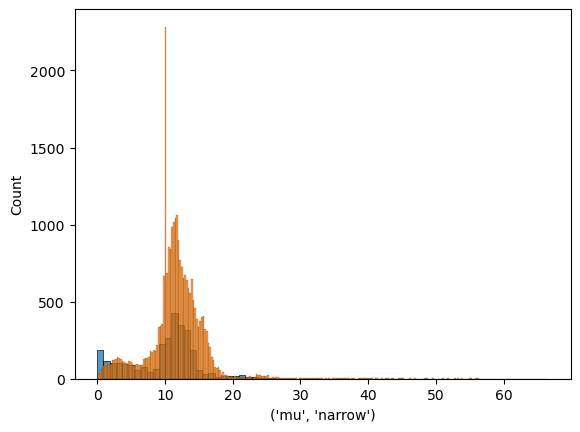

In [35]:
tmp = df.xs(14, level='model_label')
tmp = tmp[tmp[('cvr2', 'nan')] > 0.0]


sns.histplot(tmp[tmp[('sd', 'narrow')] > 1.75][('mu', 'narrow')])
sns.histplot(tmp[tmp[('sd', 'narrow')] < 1.75][('mu', 'narrow')])

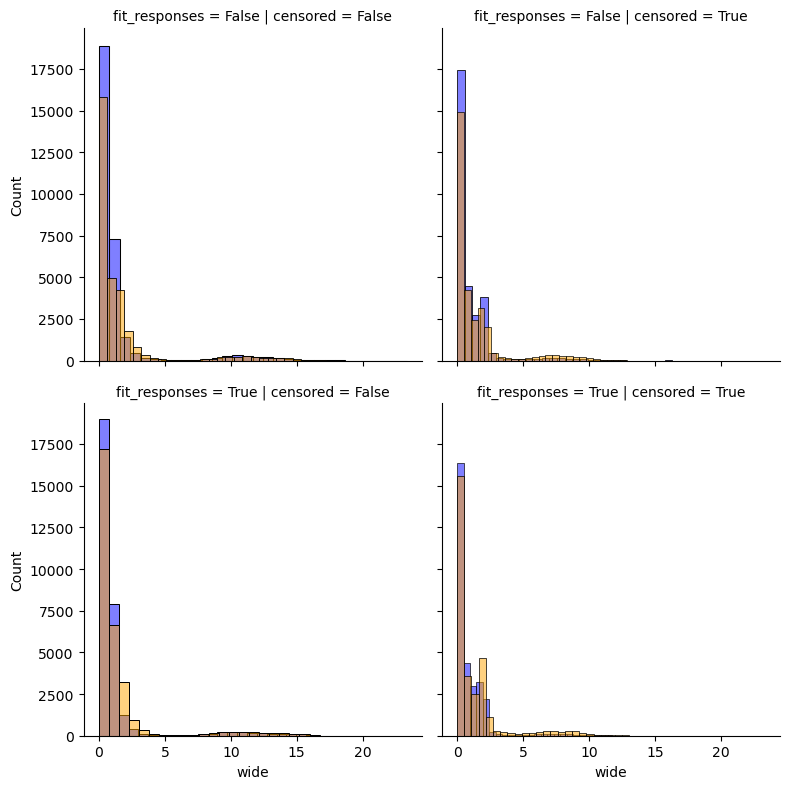

In [ ]:
g = sns.FacetGrid(df.xs(14, level='model_label')['sd'].reset_index(), row='fit_responses', col='censored', height=4)
g.map(sns.histplot, 'narrow', bins=30, color='blue', alpha=0.5)
g.map(sns.histplot, 'wide', bins=30, color='orange', alpha=0.5)

In [19]:
import pingouin as pg
median_sd = df[df[('cvr2', 'nan')] > 0.0].xs(15, level='model_label').groupby(['subject', 'censored', 'fit_responses'])['sd'].median()

median_sd.groupby(['censored', 'fit_responses']).apply(lambda x: pg.ttest(x[('sd', 'wide')], x[('sd', 'narrow')], paired=True, alternative='greater'))

T  dof alternative         p-val  \
censored fit_responses                                                   
False    False         T-test  6.764989   38     greater  2.561576e-08   
         True          T-test  8.584845   38     greater  9.906665e-11   
True     False         T-test  4.030238   38     greater  1.290652e-04   
         True          T-test  4.145412   38     greater  9.149823e-05   

                                     CI95%   cohen-d       BF10     power  
censored fit_responses                                                     
False    False         T-test  [0.11, inf]  0.576191  5.522e+05  0.970508  
         True          T-test  [0.11, inf]  0.665588   1.06e+08  0.992579  
True     False         T-test  [0.09, inf]  0.473417    207.195  0.895867  
         True          T-test  [0.08, inf]  0.578712    282.771  0.971529

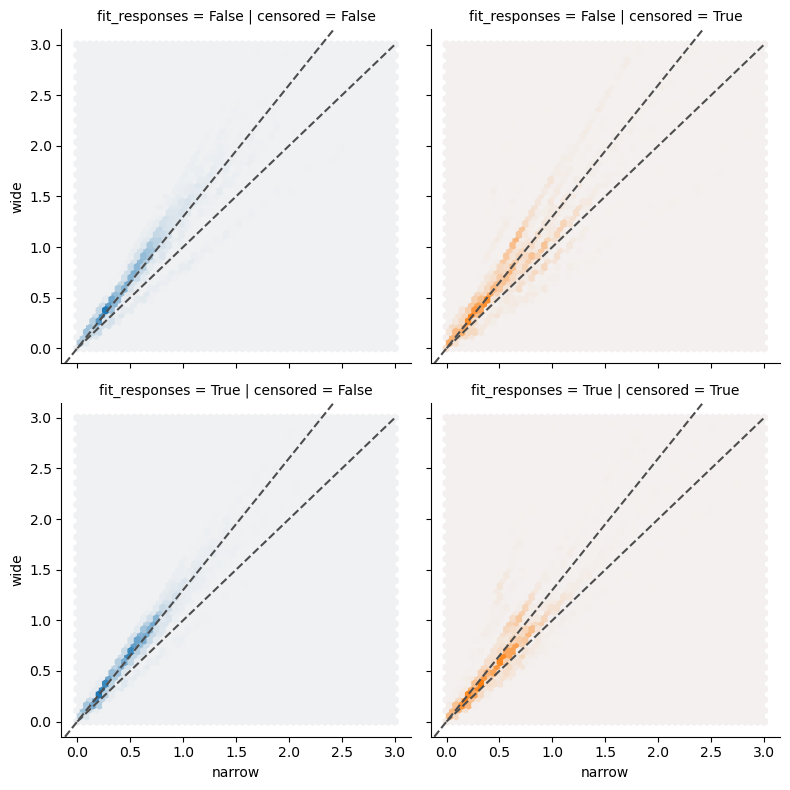

In [20]:
import matplotlib.pyplot as plt
mus = df[df[('cvr2', 'nan')] > 0.0]['sd']

max_sd = 3.0

def hexbin(x, y, color, **kwargs):
    cmap = sns.light_palette(color, as_cmap=True)
    plt.hexbin(x, y, gridsize=50, cmap=cmap, **kwargs)

g = sns.FacetGrid(mus.xs(15, level='model_label').reset_index(), col="censored", hue='censored', height=4, row='fit_responses')
g.map(hexbin, "narrow", "wide", extent=[0, max_sd, 0, max_sd])

# Identity line
for ax in g.axes.flatten():
    ax.plot([0, max_sd], [0, max_sd], ls="--", c=".3")

    ax.axline((0, 0), slope=1.3  , ls="--", c=".3")

# for ax in g.axes.flatten():
#     #plot [10, 10] to [25, 40]
#     ax.plot([10, 25], [10, 40], ls="--", c=".3")

In [21]:
slopes = df.xs(15, level='model_label')
slopes = slopes[('sd', 'wide')] / slopes[('sd', 'narrow')]

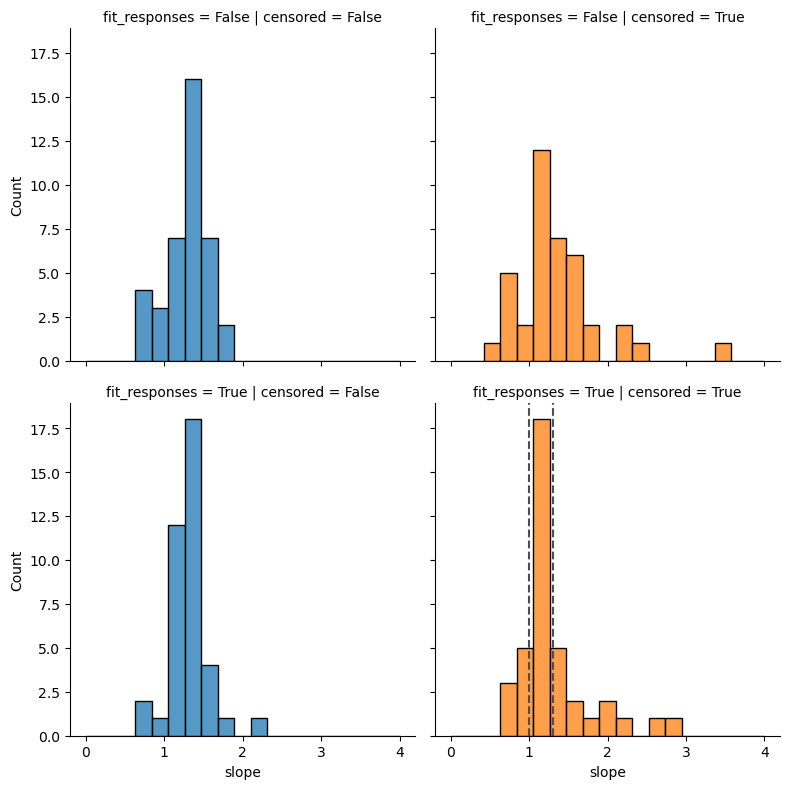

In [22]:
import numpy as np
tmp = slopes.groupby(['fit_responses', 'subject', 'censored']).mean().to_frame('slope')

g = sns.FacetGrid(tmp.reset_index(), col="censored", hue='censored', height=4, row='fit_responses')
g.map(sns.histplot, "slope", bins=np.linspace(0, 4, 20))

plt.axvline(1.0, ls="--", c=".3")
plt.axvline(1.30, ls="--", c=".3")

In [23]:
slopes.groupby(['subject', 'censored', 'fit_responses']).mean().groupby(['censored', 'fit_responses']).apply(lambda x: pg.ttest(x, 1.0, alternative='greater'))

T  dof alternative         p-val  \
censored fit_responses                                                   
False    False         T-test  7.230030   38     greater  6.018391e-09   
         True          T-test  7.716172   38     greater  1.349390e-09   
True     False         T-test  4.073877   38     greater  1.133317e-04   
         True          T-test  4.058286   38     greater  1.187256e-04   

                                     CI95%   cohen-d       BF10     power  
censored fit_responses                                                     
False    False         T-test  [1.22, inf]  1.157731  2.162e+06  1.000000  
         True          T-test  [1.24, inf]  1.235576  8.885e+06  1.000000  
True     False         T-test  [1.21, inf]  0.652342    233.007  0.990739  
         True          T-test  [1.18, inf]  0.649846    223.421  0.990351

(0.0, 4.0)

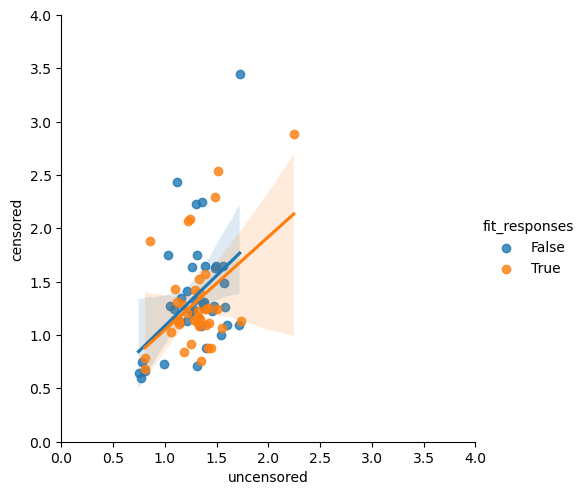

In [24]:
tmp = slopes.unstack('censored').groupby(['subject', 'fit_responses']).mean()

tmp.columns = ['uncensored', 'censored']

sns.lmplot(data=tmp.reset_index(), x='uncensored', y='censored', hue='fit_responses')
plt.xlim(0,4)
plt.ylim(0,4)

In [36]:

import numpy as np
import pandas as pd
from pathlib import Path
import pingouin as pg
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from neural_priors.utils.data import get_all_subject_ids

bids_folder = Path('/data/ds-neuralpriors')
subjects = get_all_subject_ids()
print(f'{len(subjects)} subjects')


39 subjects
